# 10 — Indicadores de congestión

Acá se calculan las tres fórmulas de CEJA. Antes de mirar un solo número, dos
advertencias que vienen de la documentación del ETL y que cambian el resultado:

1. **El denominador de la tasa de resolución no es `nuevas_ingresadas`.** El
   Anuario descompone el ingreso en varias formas (readecuadas a la Ley 439,
   recibidas por excusa o recusación, preliminares y cautelares formalizados en
   demanda…). `ingresadas` es la **suma de todas**. Usar solo una infla la tasa.
2. **`pct_resueltas`, la columna que publica el Anuario, no es la tasa de
   resolución.** El Anuario la calcula como `resueltas / atendidas`; la
   *clearance rate* estándar es `resueltas / ingresadas`. Dan números muy
   distintos y solo la segunda es comparable con el índice de CEJA.

| indicador | fórmula |
|---|---|
| tasa de resolución (*clearance rate*) | `resueltas ÷ ingresos_totales` |
| tasa de congestión | `atendidas ÷ resueltas` |
| tasa de pendencia | `pendientes_fin ÷ atendidas` |
| duración estimada (días) | `(pendientes_fin ÷ resueltas) × 365` |

La duración estimada es un estimador de **estado estacionario**: cuánto tardaría
el despacho en vaciar su stock al ritmo al que resuelve. No mide expedientes.

In [1]:
# --- Arranque -------------------------------------------------------------
# Define __file__ apuntando al script original para que las rutas del proyecto
# resuelvan igual que al correr `python src/analysis/<script>.py`.
import os, sys
from pathlib import Path

RAIZ_PROYECTO = Path.cwd().resolve()
while not (RAIZ_PROYECTO / "src" / "comun.py").exists():
    if RAIZ_PROYECTO.parent == RAIZ_PROYECTO:
        raise RuntimeError("Abrí el notebook desde dentro del repositorio.")
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

__file__ = str(RAIZ_PROYECTO / "src" / "analysis" / "10_indicadores_congestion.py")
os.chdir(RAIZ_PROYECTO)
sys.path.insert(0, str(RAIZ_PROYECTO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# Paleta categórica validada (separación CVD ΔE 9,1; contraste bajo en verde y
# ámbar, por eso todos los gráficos llevan el valor escrito encima).
AZUL, NARANJA, VERDE, AMBAR = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA_2, RULE = "#15202a", "#56606b", "#d9d6ce"
RAMPA_AZUL = ["#eaf2fd", "#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9.5, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": RULE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.55, "grid.color": RULE,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False,
})

import textwrap

def envolver(texto, ancho=17):
    """Parte un rótulo largo en varias líneas en vez de truncarlo."""
    return textwrap.fill(str(texto), ancho)

def etiquetar_barh(ax, valores, fmt="{:,.0f}", dx=None):
    """Escribe el valor al final de cada barra horizontal."""
    dx = dx if dx is not None else max(valores) * 0.012
    for i, v in enumerate(valores):
        ax.text(v + dx, i, fmt.format(v), va="center", fontsize=9,
                fontweight="bold", color=TINTA)

print("raíz:", RAIZ_PROYECTO)

raíz: C:\maxi\u\anal\congestion-judicial-bolivia


In [2]:
from analysis.nulos import clasificar_dinamica_procesal
from analysis.metricas import (calcular_indicadores_congestion,
                               verificar_identidad_ingresos,
                               COLUMNAS_INGRESOS)

DATA = RAIZ_PROYECTO / "data/processed/analitico/dataset_analitico_interno.parquet"
OUT_FEATURES = RAIZ_PROYECTO / "data/curated/features"
OUT_EDA = RAIZ_PROYECTO / "data/curated/eda"
OUT_FEATURES.mkdir(parents=True, exist_ok=True)
OUT_EDA.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA)
df["estado_gestion"] = clasificar_dinamica_procesal(df)
columnas_originales = [c for c in df.columns if c != "estado_gestion"]
print(f"entrada: {len(df):,} filas x {len(df.columns)} columnas")

entrada: 1,997 filas x 88 columnas


## 1. Las formas de ingreso

Antes de dividir por `ingresadas` conviene ver de qué está hecha. Estas son las
ocho columnas que el Anuario publica como formas de ingreso, y cuánto aporta
cada una en el estrato de procesos.

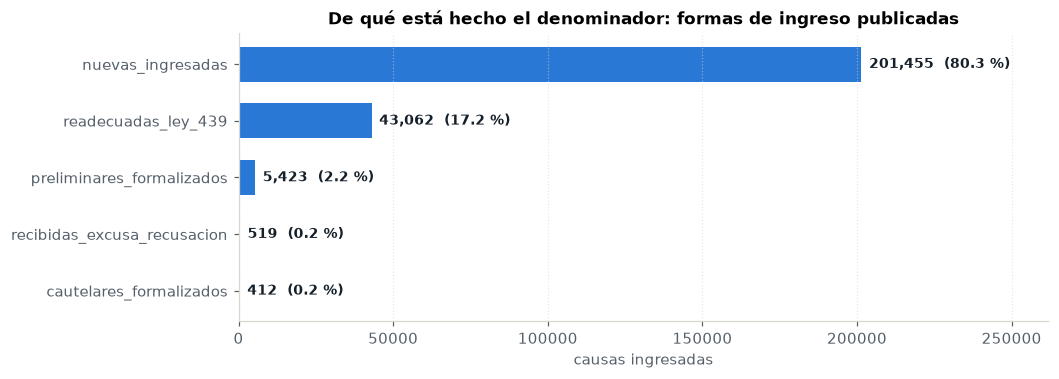

Si se usara solo `nuevas_ingresadas` se perdería el 19.7 % del denominador.


In [3]:
proc_in = df[df["tipo_elemento_analitico"] == "proceso"]
presentes = [c for c in COLUMNAS_INGRESOS if c in df.columns]
aporte = (proc_in[presentes].fillna(0).sum()
          .sort_values(ascending=True))
aporte = aporte[aporte > 0]
pct_ap = aporte / aporte.sum() * 100

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.barh(aporte.index, aporte.values, color=AZUL, height=.62)
for i, (v, p) in enumerate(zip(aporte.values, pct_ap.values)):
    ax.text(v + aporte.max() * .012, i, f"{v:,.0f}  ({p:.1f} %)", va="center",
            fontsize=9, fontweight="bold", color=TINTA)
ax.set_xlim(0, aporte.max() * 1.3)
ax.set_xlabel("causas ingresadas")
ax.set_title("De qué está hecho el denominador: formas de ingreso publicadas")
ax.grid(axis="y", visible=False)
plt.show()

print(f"Si se usara solo `nuevas_ingresadas` se perdería el "
      f"{100 - pct_ap.get('nuevas_ingresadas', 0):.1f} % del denominador.")

## 2. El control duro

La suma de las formas de ingreso tiene que reproducir la identidad contable del
propio Anuario: `ingresadas == atendidas − pendientes_inicio`. El script **aborta**
si no cierra en el estrato `proceso`. Los cuadros penales publican otro juego de
columnas y no cierran esta identidad: quedan fuera del cálculo, y se informa
cuántas filas son.

In [4]:
es_proceso = df["tipo_elemento_analitico"] == "proceso"
df_ind = calcular_indicadores_congestion(df)

descuadres = verificar_identidad_ingresos(df_ind, mascara=es_proceso)
assert descuadres.empty, f"{len(descuadres)} filas no cierran la identidad"

# Cobertura real del control: la funcion solo compara filas donde `atendidas` y
# `pendientes_inicio` estan publicados. Las que no tienen stock inicial NO son
# comparables y quedan fuera, asi que conviene decir sobre cuantas se verifico.
comparables = es_proceso & df_ind["atendidas"].notna() & df_ind["pendientes_inicio"].notna()
omitidas = int(es_proceso.sum()) - int(comparables.sum())
print(f"[OK] identidad verificada, 0 descuadres")
print(f"     filas del estrato 'proceso'      : {int(es_proceso.sum()):,}")
print(f"     realmente comparables            : {int(comparables.sum()):,}")
print(f"     omitidas por no publicar stock   : {omitidas:,}")

sin_stock = (df_ind.loc[es_proceso & df_ind["pendientes_inicio"].isna(), "materia_homologada"]
             .value_counts())
if len(sin_stock):
    print()
    print("     materias sin `pendientes_inicio` publicado:")
    for mat, n in sin_stock.items():
        print(f"       - {mat}: {n:,} filas")

fuera = verificar_identidad_ingresos(df_ind, mascara=~es_proceso)
print(f"[nota] {len(fuera)} filas penales no cierran la identidad y quedan fuera "
      f"del cálculo de indicadores (publican otras columnas de ingreso)")

[OK] identidad verificada, 0 descuadres
     filas del estrato 'proceso'      : 1,655
     realmente comparables            : 1,180
     omitidas por no publicar stock   : 475

     materias sin `pendientes_inicio` publicado:
       - Público Civil y Comercial: 475 filas
[nota] 89 filas penales no cierran la identidad y quedan fuera del cálculo de indicadores (publican otras columnas de ingreso)


> **Consecuencia que hay que tener presente.** Donde el Anuario no publica
> `pendientes_inicio`, la suma de formas de ingreso termina siendo igual a
> `atendidas`. En esas filas el *clearance rate* se vuelve `resueltas / atendidas`
> — que es exactamente la fórmula de `pct_resueltas` del Anuario, la que la
> documentación advierte que **no** es la tasa de resolución. Para esas materias
> el indicador no es comparable con el de las demás, y el notebook 12 lo repite
> al presentar los resultados.

## 3. Tratamiento aditivo nº 1: las columnas que agrega este paso

Regla del repositorio: **ningún tratamiento sobrescribe ni elimina**. Cada paso
agrega columnas nuevas y deja intactas las anteriores. Este es el inventario de
lo que agrega el paso 10.

In [5]:
nuevas = [c for c in df_ind.columns if c not in df.columns]
descripcion = {
    "ingresos_totales": "suma de las 8 formas de ingreso publicadas",
    "tasa_resolucion": "clearance rate = resueltas / ingresos_totales",
    "tasa_resolucion_solo_nuevas": "variante sobre nuevas_ingresadas — NO es el CR",
    "tasa_congestion": "atendidas / resueltas",
    "tasa_pendencia": "pendientes_fin / atendidas",
    "duracion_estimada_dias": "(pendientes_fin / resueltas) x 365",
    "acumulacion_neta_anual": "ingresos_totales - resueltas",
    "flag_acumula_mora": "bool: tasa_resolucion < 1,0",
    "flag_sin_resolucion_anual": "bool: atendidas > 0 y resueltas == 0",
    "flag_sin_movimiento": "bool: atendidas == 0",
    "atendidas_por_item_personal": "carga relativa al personal del distrito",
    "atendidas_por_juzgado_territorio": "carga relativa a juzgados publicados",
}
inventario = pd.DataFrame({
    "columna_nueva": nuevas,
    "tipo": [str(df_ind[c].dtype) for c in nuevas],
    "no_nulos": [int(df_ind[c].notna().sum()) for c in nuevas],
    "pct_poblada": [round(df_ind[c].notna().mean() * 100, 1) for c in nuevas],
    "qué hace": [descripcion.get(c, "") for c in nuevas],
})
print(f"columnas antes: {len(df.columns)}   después: {len(df_ind.columns)}   "
      f"agregadas: {len(nuevas)}")
inventario

columnas antes: 88   después: 100   agregadas: 12


,columna_nueva,tipo,no_nulos,pct_poblada,qué hace
0,ingresos_totales,float64,1997,100.0,suma de las 8 formas de ingreso publicadas
1,tasa_resolucion,float64,1218,61.0,clearance rate = resueltas / ingresos_totales
2,tasa_resolucion_solo_nuevas,float64,1198,60.0,variante sobre nuevas_ingresadas — NO es el CR
3,tasa_congestion,float64,1173,58.7,atendidas / resueltas
4,tasa_pendencia,float64,1997,100.0,pendientes_fin / atendidas
5,duracion_estimada_dias,float64,1173,58.7,(pendientes_fin / resueltas) x 365
6,acumulacion_neta_anual,float64,1712,85.7,ingresos_totales - resueltas
7,flag_acumula_mora,bool,1997,100.0,"bool: tasa_resolucion < 1,0"
8,flag_sin_resolucion_anual,bool,1997,100.0,bool: atendidas > 0 y resueltas == 0
9,flag_sin_movimiento,bool,1997,100.0,bool: atendidas == 0


In [6]:
# Verificación de que el tratamiento fue estrictamente aditivo.
intactas = df_ind[columnas_originales].equals(df[columnas_originales])
print(f"filas preservadas            : {len(df_ind):,} / {len(df):,}")
print(f"columnas originales intactas : {intactas}")
assert intactas and len(df_ind) == len(df) == 1997

filas preservadas            : 1,997 / 1,997
columnas originales intactas : True


## 4. Cómo se distribuyen los indicadores

Tres histogramas sobre el estrato de procesos. La línea marca la mediana; la
línea punteada, el umbral que separa "descarga acumulado" de "acumula mora".

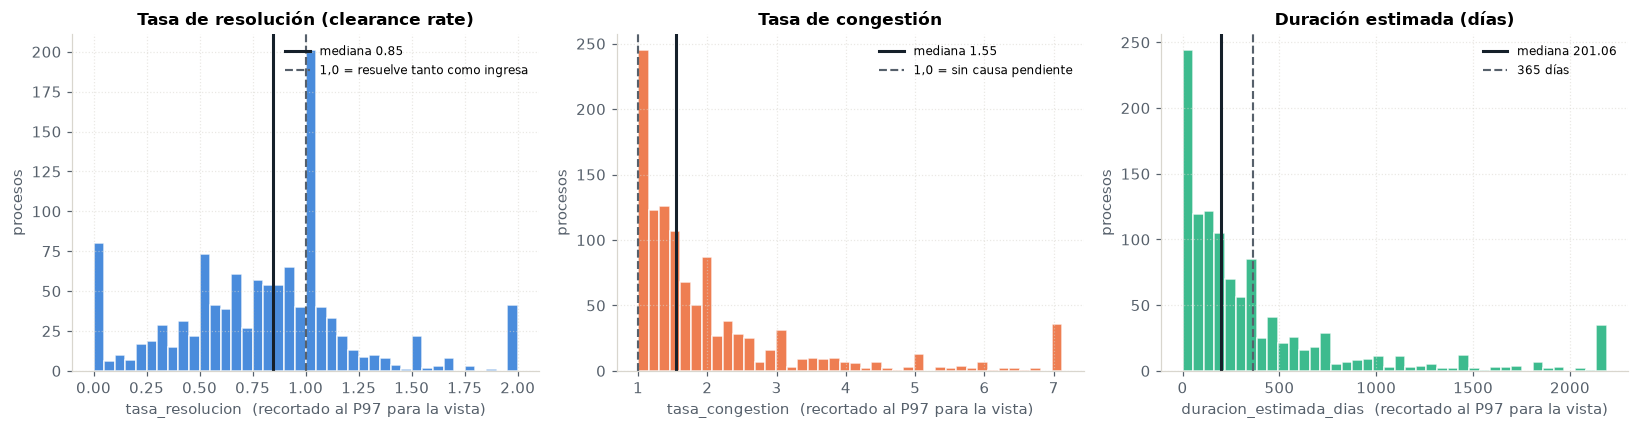

,count,mean,std,min,25%,50%,75%,95%,max,pct_nulos
tasa_resolucion,1168.0,0.98,4.83,0.0,0.52,0.85,1.00,1.52,164.0,29.4
tasa_congestion,1122.0,2.24,3.08,1.0,1.20,1.55,2.28,5.60,81.0,32.2
tasa_pendencia,1655.0,0.32,0.32,0.0,0.00,0.26,0.54,1.00,1.0,0.0
duracion_estimada_dias,1122.0,446.68,1111.73,0.0,73.00,201.06,464.25,1641.67,29200.0,32.2


In [7]:
p = df_ind[df_ind["tipo_elemento_analitico"] == "proceso"]

specs = [
    ("tasa_resolucion", "Tasa de resolución (clearance rate)", AZUL, 1.0,
     "1,0 = resuelve tanto como ingresa"),
    ("tasa_congestion", "Tasa de congestión", NARANJA, 1.0,
     "1,0 = sin causa pendiente"),
    ("duracion_estimada_dias", "Duración estimada (días)", VERDE, 365.0,
     "365 días"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, titulo, color, ref, nota) in zip(axes, specs):
    s = p[col].dropna()
    tope = s.quantile(.97)
    ax.hist(s.clip(upper=tope), bins=40, color=color, alpha=.85, edgecolor="white")
    ax.axvline(s.median(), color=TINTA, lw=2, label=f"mediana {s.median():,.2f}")
    ax.axvline(ref, color=TINTA_2, lw=1.4, ls="--", label=nota)
    ax.set_title(titulo)
    ax.set_xlabel(f"{col}  (recortado al P97 para la vista)")
    ax.set_ylabel("procesos")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

resumen_dist = p[["tasa_resolucion", "tasa_congestion", "tasa_pendencia",
                  "duracion_estimada_dias"]].describe(
    percentiles=[.25, .5, .75, .95]).T.round(2)
resumen_dist["pct_nulos"] = [(100 - p[c].notna().mean() * 100).round(1)
                             for c in resumen_dist.index]
resumen_dist

Las tres distribuciones tienen cola derecha larga y algunas son infinitas por
construcción: un despacho con `resueltas == 0` no tiene tasa de congestión
definida. Eso queda **nulo**, no imputado — y es exactamente lo que el paso 11
va a tratar, sin borrar nada.

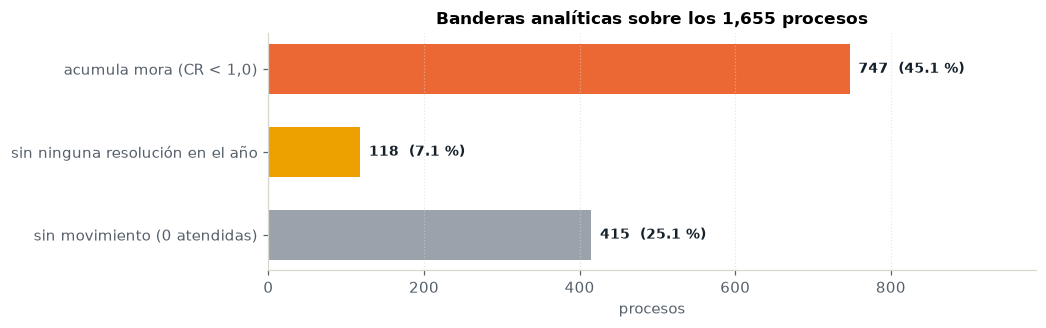

In [8]:
flags = [("flag_acumula_mora", "acumula mora (CR < 1,0)", NARANJA),
         ("flag_sin_resolucion_anual", "sin ninguna resolución en el año", AMBAR),
         ("flag_sin_movimiento", "sin movimiento (0 atendidas)", "#9aa3ab")]
vals = [int(p[c].sum()) for c, _, _ in flags]
pcts = [v / len(p) * 100 for v in vals]

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.barh([e for _, e, _ in flags][::-1], vals[::-1],
        color=[c for _, _, c in flags][::-1], height=.6)
for i, (v, q) in enumerate(zip(vals[::-1], pcts[::-1])):
    ax.text(v + max(vals) * .015, i, f"{v:,}  ({q:.1f} %)", va="center",
            fontsize=9, fontweight="bold", color=TINTA)
ax.set_xlim(0, max(vals) * 1.32)
ax.set_xlabel("procesos")
ax.set_title(f"Banderas analíticas sobre los {len(p):,} procesos")
ax.grid(axis="y", visible=False)
plt.show()

## 5. Agregado por materia

Las medianas describen al despacho típico; las ponderadas describen al sistema.
No son lo mismo y conviene mirar las dos.

In [9]:
p_val = p[p["resueltas"].notnull() & (p["atendidas"] > 0)]
resumen_mat = p_val.groupby("materia_homologada").agg(
    total_procesos=("tipo_proceso", "count"),
    ingresos_total=("ingresos_totales", "sum"),
    atendidas_total=("atendidas", "sum"),
    resueltas_total=("resueltas", "sum"),
    pendientes_total=("pendientes_fin", "sum"),
    cr_mediana=("tasa_resolucion", "median"),
    congestion_mediana=("tasa_congestion", "median"),
    duracion_dias_mediana=("duracion_estimada_dias", "median"),
).reset_index()

resumen_mat["clearance_rate_ponderado"] = resumen_mat["resueltas_total"] / resumen_mat["ingresos_total"].replace(0, pd.NA)
resumen_mat["tasa_congestion_ponderada"] = resumen_mat["atendidas_total"] / resumen_mat["resueltas_total"].replace(0, pd.NA)
resumen_mat["duracion_dias_ponderada"] = (resumen_mat["pendientes_total"] / resumen_mat["resueltas_total"].replace(0, pd.NA)) * 365
resumen_mat.round(2)

,materia_homologada,total_procesos,ingresos_total,atendidas_total,resueltas_total,pendientes_total,cr_mediana,congestion_mediana,duracion_dias_mediana,clearance_rate_ponderado,tasa_congestion_ponderada,duracion_dias_ponderada
0,Partido Administrativo Coactivo Fiscal y Tribu...,30,2012.0,13249,2671,10368,1.00,2.87,582.48,1.33,4.96,1416.82
1,Partido de Trabajo y Seguridad Social,152,24073.0,51342,23441,27901,1.00,2.00,365.00,0.97,2.19,434.45
2,Público Civil y Comercial,384,136874.0,136874,94769,42105,0.57,1.65,236.28,0.69,1.44,162.17
3,Público Niñez y Adolescencia,325,9546.0,13524,9106,4418,0.99,1.31,112.86,0.95,1.49,177.09
4,Público de Familia,349,78366.0,120483,79210,41273,1.00,1.50,182.50,1.01,1.52,190.19


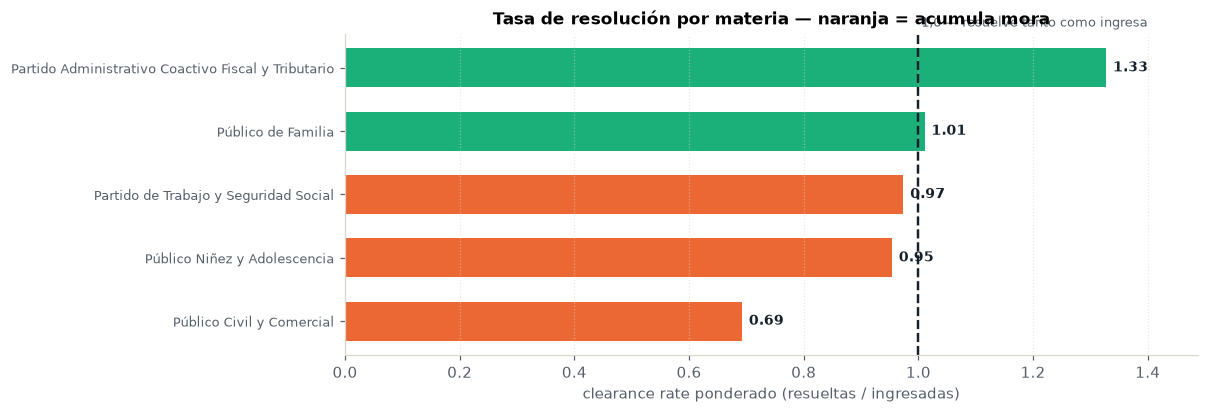

In [10]:
r = resumen_mat.sort_values("clearance_rate_ponderado")
y = np.arange(len(r))
fig, ax = plt.subplots(figsize=(10, 3.8))
colores = [NARANJA if v < 1 else VERDE for v in r["clearance_rate_ponderado"]]
ax.barh(y, r["clearance_rate_ponderado"].astype(float), color=colores, height=.62)
ax.axvline(1.0, color=TINTA, lw=1.6, ls="--")
ax.text(1.005, len(r) - .35, "1,0 — resuelve tanto como ingresa", fontsize=8.5, color=TINTA_2)
for i, v in enumerate(r["clearance_rate_ponderado"].astype(float)):
    ax.text(v + .012, i, f"{v:.2f}", va="center", fontsize=9, fontweight="bold", color=TINTA)
ax.set_yticks(y); ax.set_yticklabels(r["materia_homologada"], fontsize=8.5)
ax.set_xlim(0, max(1.05, r["clearance_rate_ponderado"].max() * 1.12))
ax.set_xlabel("clearance rate ponderado (resueltas / ingresadas)")
ax.set_title("Tasa de resolución por materia — naranja = acumula mora")
ax.grid(axis="y", visible=False)
plt.show()

## 6. Artefactos

In [11]:
df_ind.to_parquet(OUT_FEATURES / "dataset_analitico_indicadores.parquet", index=False)
df_ind.to_csv(OUT_FEATURES / "dataset_analitico_indicadores.csv", index=False, encoding="utf-8")
resumen_mat.to_csv(OUT_EDA / "resumen_indicadores_materia.csv", index=False, encoding="utf-8")

print("escritos:")
print("  data/curated/features/dataset_analitico_indicadores.parquet")
print("  data/curated/features/dataset_analitico_indicadores.csv")
print("  data/curated/eda/resumen_indicadores_materia.csv")
print(f"\n{len(df.columns)} columnas -> {len(df_ind.columns)} columnas "
      f"(+{len(nuevas)} aditivas, 0 sobrescritas, 0 filas eliminadas)")

escritos:
  data/curated/features/dataset_analitico_indicadores.parquet
  data/curated/features/dataset_analitico_indicadores.csv
  data/curated/eda/resumen_indicadores_materia.csv

88 columnas -> 100 columnas (+12 aditivas, 0 sobrescritas, 0 filas eliminadas)
